In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 1: IMPORT LIBRARIES
# We only need libraries that are pre-installed in Google Colab
# so no pip install is required
# ─────────────────────────────────────────────────────────────

import pandas as pd          # For creating and managing the dataset as a DataFrame
import numpy as np           # For numerical operations like array sorting
from sklearn.feature_extraction.text import TfidfVectorizer  # Converts text into TF-IDF vectors
from sklearn.metrics.pairwise import cosine_similarity       # Measures similarity between vectors
import matplotlib.pyplot as plt       # For plotting bar charts
import matplotlib.patches as mpatches # For adding a custom color legend to the chart
import textwrap                        # For wrapping long text neatly in the terminal output

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 2: CREATE THE KNOWLEDGE BASE DATASET
# We manually define 34 records covering 3 categories:
#   - Service Description : what CoreTech offers
#   - FAQ                 : common customer questions & answers
#   - Company Info        : background, leadership, offices, CSR
# Each record has: (id, category, title, content)
# ─────────────────────────────────────────────────────────────

data = [
  # ── SERVICE DESCRIPTIONS (records 1–10, 31) ──────────────────────────────

  (1,  'Service Description', 'Cloud Hosting Services',
   'CoreTech offers scalable cloud hosting solutions for businesses of all sizes. Our infrastructure is built on enterprise-grade servers with 99.9% uptime guarantee, automatic backups, and 24/7 monitoring. Plans start from $10/month for startups to enterprise-level custom packages.'),

  (2,  'Service Description', 'Managed IT Support',
   'Our Managed IT Support team provides round-the-clock technical assistance to ensure your business runs smoothly. Services include helpdesk support, network monitoring, patch management, and proactive maintenance to prevent downtime before it happens.'),

  (3,  'Service Description', 'Cybersecurity Solutions',
   'CoreTech cybersecurity suite includes firewall management, intrusion detection, endpoint protection, and security audits. We help businesses stay compliant with GDPR, HIPAA, and ISO 27001 standards while defending against modern cyber threats.'),

  (4,  'Service Description', 'Software Development',
   'We build custom web and mobile applications tailored to your business needs. Our development team uses modern stacks including React, Node.js, Python, and Flutter. We follow agile methodology ensuring transparent communication and timely delivery.'),

  (5,  'Service Description', 'Data Analytics & Business Intelligence',
   'CoreTech transforms raw business data into actionable insights through dashboards, reports, and predictive models. We use tools like Power BI, Tableau, and custom Python pipelines to help companies make data-driven decisions.'),

  (6,  'Service Description', 'Network Infrastructure Setup',
   'We design and deploy robust network infrastructure including LAN/WAN setup, VPN configuration, Wi-Fi optimization, and hardware procurement. Our certified engineers ensure your network is fast, secure, and scalable.'),

  (7,  'Service Description', 'IT Consultancy',
   'Our IT consultants work with your leadership team to align technology strategy with business goals. Services include digital transformation roadmaps, technology audits, vendor selection, and ROI analysis for IT investments.'),

  (8,  'Service Description', 'DevOps & Cloud Automation',
   'CoreTech DevOps team implements CI/CD pipelines, container orchestration with Kubernetes, infrastructure as code using Terraform, and automated testing to accelerate your software delivery lifecycle.'),

  (9,  'Service Description', 'Backup & Disaster Recovery',
   'We provide automated backup solutions and disaster recovery planning to protect your critical business data. Our systems ensure recovery time objectives (RTO) of under 4 hours and recovery point objectives (RPO) of under 1 hour.'),

  (10, 'Service Description', 'VoIP & Communication Systems',
   'CoreTech deploys enterprise VoIP systems and unified communication platforms including Microsoft Teams integration, IP PBX setup, video conferencing, and call center solutions for seamless business communication.'),

  # ── FAQs (records 11–23, 32–33) ──────────────────────────────────────────

  (11, 'FAQ', 'How do I contact CoreTech support?',
   'You can reach our support team 24/7 via email at support@coretech.com, by phone at +1-800-CORETECH, or through the live chat on our website. Average response time is under 15 minutes.'),

  (12, 'FAQ', 'What is the SLA for Managed IT Support?',
   'Our standard Service Level Agreement guarantees a 1-hour response time for critical issues, 4 hours for high-priority tickets, and 8 business hours for medium-priority requests.'),

  (13, 'FAQ', 'How does CoreTech ensure data security?',
   'CoreTech employs AES-256 encryption for data at rest and TLS 1.3 for data in transit. We conduct quarterly penetration testing, maintain SOC 2 Type II certification, and follow zero-trust security architecture principles.'),

  (14, 'FAQ', 'Can I upgrade or downgrade my cloud plan?',
   'Yes, plan changes can be made at any time through the CoreTech client portal. Upgrades take effect immediately while downgrades apply at the next billing cycle. There are no cancellation fees.'),

  (15, 'FAQ', 'Does CoreTech offer free trials?',
   'We offer a 14-day free trial for our Cloud Hosting and Managed IT Support services. No credit card is required to start a trial. After the trial, you can choose any plan or cancel with no obligations.'),

  (16, 'FAQ', 'What industries does CoreTech serve?',
   'CoreTech serves healthcare, finance, education, retail, manufacturing, and government. We have specialized compliance expertise for HIPAA in healthcare and PCI-DSS for financial services.'),

  (17, 'FAQ', 'How long does software development take?',
   'A basic web application typically takes 4 to 8 weeks, while complex enterprise systems may take 3 to 6 months. We provide a detailed project plan with milestones after the initial discovery phase.'),

  (18, 'FAQ', 'What happens if my server goes down?',
   'Our monitoring systems detect outages within 60 seconds and on-call engineers are automatically alerted. For managed hosting clients, we initiate failover procedures immediately and notify clients via SMS and email.'),

  (19, 'FAQ', 'Do you offer on-site IT support?',
   'Yes, CoreTech provides on-site IT support for clients in major cities. On-site visits can be scheduled through the client portal or by calling your dedicated account manager.'),

  (20, 'FAQ', 'How do I reset my CoreTech portal password?',
   'Visit portal.coretech.com and click Forgot Password. Enter your registered email address and you will receive a reset link within 2 minutes. Reset links expire after 30 minutes for security.'),

  (21, 'FAQ', 'What payment methods does CoreTech accept?',
   'CoreTech accepts all major credit cards, bank wire transfers, and PayPal for international clients. Invoiced billing on NET-30 terms is available for enterprise and government accounts.'),

  (22, 'FAQ', 'Can CoreTech migrate my existing systems?',
   'Yes, we offer full migration services for websites, databases, email systems, and on-premise servers to cloud environments using zero-downtime blue-green deployment strategies.'),

  (23, 'FAQ', 'Is there a setup fee for new services?',
   'Most CoreTech services have no setup fee. Complex network deployments or custom software projects may include a one-time onboarding fee clearly outlined in your proposal before any agreement is signed.'),

  # ── COMPANY INFO (records 24–30, 34) ─────────────────────────────────────

  (24, 'Company Info', 'About CoreTech',
   'CoreTech Solutions was founded in 2010 with a mission to make enterprise-grade technology accessible to businesses of all sizes. Headquartered in San Francisco, CA, CoreTech employs over 500 IT professionals across offices in New York, London, Dubai, and Karachi.'),

  (25, 'Company Info', 'CoreTech Mission & Vision',
   'Our mission is to empower businesses through innovative technology solutions that drive growth and efficiency. Our vision is to be the most trusted technology partner for SMEs and enterprises globally.'),

  (26, 'Company Info', 'CoreTech Leadership Team',
   'CoreTech is led by CEO Sarah Mitchell, a veteran technology executive with 20+ years in the industry. The leadership team includes CTO David Chen, COO Priya Sharma, and CFO Marcus Thompson.'),

  (27, 'Company Info', 'CoreTech Awards & Certifications',
   'CoreTech holds ISO 27001, SOC 2 Type II, and CMMI Level 3 certifications. We are a Microsoft Gold Partner and AWS Advanced Consulting Partner, and were named Best IT Company of the Year 2023 by TechAwards Global.'),

  (28, 'Company Info', 'CoreTech Corporate Social Responsibility',
   'CoreTech operates on 100% renewable energy in our data centers, runs a STEM scholarship program for underprivileged students, and donates 1% of annual profits to digital literacy programs in developing nations.'),

  (29, 'Company Info', 'CoreTech Partner Ecosystem',
   'CoreTech partners with Microsoft, AWS, Google Cloud, Cisco, and Dell Technologies. These partnerships allow us to offer clients best-in-class technology at negotiated rates with priority vendor support.'),

  (30, 'Company Info', 'CoreTech Office Locations',
   'CoreTech global offices: HQ in San Francisco CA USA | New York NY | London UK | Dubai DIFC | Karachi Dolmen City Clifton. Each office provides local support and sales for regional clients.'),

  (31, 'Service Description', 'Email & Microsoft 365 Management',
   'CoreTech manages Microsoft 365 and Google Workspace deployments including email hosting, SharePoint, Teams, OneDrive, and license management. We handle migrations, user provisioning, and ongoing administration.'),

  (32, 'FAQ', 'How does billing work for cloud services?',
   'Cloud services are billed monthly based on actual resource consumption. You receive a detailed invoice on the 1st of each month showing compute, storage, and bandwidth usage. Budget alerts can be configured to control spending.'),

  (33, 'FAQ', 'Does CoreTech provide employee IT training?',
   'Yes, we offer IT training workshops covering cybersecurity awareness, Microsoft 365, cloud tools, and productivity software. Training can be conducted on-site, virtually, or through our self-paced online learning portal.'),

  (34, 'Company Info', 'CoreTech Data Center Infrastructure',
   'CoreTech operates Tier 3 data centers in the US, UK, and UAE with redundant power supplies, cooling systems, and fiber connectivity. Each facility has biometric access, 24/7 CCTV surveillance, and on-site security personnel.'),
]

# Convert the list of tuples into a pandas DataFrame with named columns
df = pd.DataFrame(data, columns=['id', 'category', 'title', 'content'])

# Save the DataFrame as a CSV file in Colab's working directory
# You can download this later from the Files panel on the left sidebar
df.to_csv('coretech_knowledge_base.csv', index=False)

print(f"✅ Dataset created with {len(df)} records")
print(f"   Categories: {df['category'].value_counts().to_dict()}")

# Preview first 5 rows in a formatted table
df.head()

✅ Dataset created with 34 records
   Categories: {'FAQ': 15, 'Service Description': 11, 'Company Info': 8}


,id,category,title,content
0,1,Service Description,Cloud Hosting Services,CoreTech offers scalable cloud hosting solutio...
1,2,Service Description,Managed IT Support,Our Managed IT Support team provides round-the...
2,3,Service Description,Cybersecurity Solutions,CoreTech cybersecurity suite includes firewall...
3,4,Service Description,Software Development,We build custom web and mobile applications ta...
4,5,Service Description,Data Analytics & Business Intelligence,CoreTech transforms raw business data into act...


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 3: BUILD THE TF-IDF INDEX
#
# TF-IDF stands for Term Frequency–Inverse Document Frequency
#
# TF  (Term Frequency)         = how often a word appears in ONE document
# IDF (Inverse Doc Frequency)  = how rare that word is across ALL documents
# TF-IDF score                 = TF × IDF
#
# Words that are frequent in a specific document BUT rare overall
# get a HIGH score → they are good identifiers for that document.
# Common words like "the", "is", "we" get LOW scores → less useful.
# ─────────────────────────────────────────────────────────────

# Step 1: Create a combined search field by merging title + content
# This gives the title words extra weight since they appear twice
df['search_text'] = df['title'] + ' ' + df['content']

# Step 2: Configure and build the TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    stop_words='english',   # Automatically remove common English words (the, is, and, etc.)
    ngram_range=(1, 2),     # Consider both single words AND two-word phrases (e.g. "cloud hosting")
    max_df=0.9,             # Ignore words that appear in more than 90% of documents (too common)
    min_df=1,               # Keep words that appear in at least 1 document
    sublinear_tf=True       # Use log(1 + tf) instead of raw tf to reduce dominance of very frequent words
)

# Step 3: Fit the vectorizer on all documents and transform them into a matrix
# tfidf_matrix shape: (number of documents) × (number of unique terms)
# Each row = one document represented as a vector of TF-IDF scores
tfidf_matrix = vectorizer.fit_transform(df['search_text'])

print("✅ TF-IDF index built successfully!")
print(f"   Documents indexed : {tfidf_matrix.shape[0]}")
print(f"   Vocabulary size   : {tfidf_matrix.shape[1]} unique terms")

✅ TF-IDF index built successfully!
   Documents indexed : 34
   Vocabulary size   : 1305 unique terms


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 4: DEFINE THE SEMANTIC SEARCH FUNCTION
#
# HOW COSINE SIMILARITY WORKS:
# Each document and the query are represented as vectors in
# high-dimensional space (one dimension per vocabulary term).
#
# Cosine similarity measures the ANGLE between two vectors:
#   similarity = (A · B) / (||A|| × ||B||)
#
#   Score = 1.0  →  Identical direction  →  Perfect match
#   Score = 0.0  →  Perpendicular        →  No match at all
#
# We don't care about vector magnitude (document length),
# only direction — so longer documents aren't unfairly favoured.
# ─────────────────────────────────────────────────────────────

def semantic_search(query, top_k=3):
    """
    Search the CoreTech knowledge base using TF-IDF + Cosine Similarity.

    Parameters:
        query  (str) : A natural language question or keyword string
        top_k  (int) : Number of top results to return (default = 3)

    Returns:
        pd.DataFrame : Columns → rank, similarity_score, category, title, content
    """

    # Step 1: Transform the user query into a TF-IDF vector
    # We use transform() (NOT fit_transform) so the same vocabulary
    # learned from the knowledge base is used — no new words are added
    query_vec = vectorizer.transform([query])

    # Step 2: Compute cosine similarity between the query vector
    # and EVERY document vector in the TF-IDF matrix
    # Result is a 1D array of scores, one score per document
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # Step 3: Sort scores in descending order and take the top-k indices
    # argsort() returns indices from lowest to highest → [::-1] reverses it
    # [:top_k] slices only the top k indices
    top_indices = scores.argsort()[::-1][:top_k]

    # Step 4: Use those indices to pull the matching rows from the DataFrame
    results = df.iloc[top_indices][['category', 'title', 'content']].copy()

    # Step 5: Attach the similarity scores and rank numbers to the results
    results['similarity_score'] = scores[top_indices].round(4)
    results.insert(0, 'rank', range(1, top_k + 1))  # Add rank column at position 0
    results = results.reset_index(drop=True)         # Clean up index numbering

    return results


def display_results(query, results):
    """
    Pretty-print search results with a visual similarity bar,
    category, title, and a snippet of the content.
    """

    print('=' * 70)
    print(f' 🔍  QUERY: "{query}"')
    print('=' * 70)

    # Handle edge case: all scores are 0 (no relevant match found)
    if results['similarity_score'].max() == 0:
        print('⚠️  No relevant results found. Try different keywords.')
        return

    for _, row in results.iterrows():
        # Build a visual bar proportional to the similarity score
        # e.g. score 0.6 → 18 filled blocks out of 30
        bar_len = int(row['similarity_score'] * 30)
        bar = '█' * bar_len + '░' * (30 - bar_len)

        print(f"\n  Rank #{int(row['rank'])}  [{bar}]  Score: {row['similarity_score']:.4f}")
        print(f"  📂 Category : {row['category']}")
        print(f"  📌 Title    : {row['title']}")

        # Truncate content to 300 characters and wrap it neatly for readability
        snippet = textwrap.fill(
            row['content'][:300] + ('...' if len(row['content']) > 300 else ''),
            width=66,
            initial_indent='  📄 Content  : ',      # First line indent
            subsequent_indent='               '      # Continuation line indent
        )
        print(snippet)

    print('\n' + '=' * 70)


print("✅ Search functions defined — ready to query!")

✅ Search functions defined — ready to query!


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 5: RUN EXAMPLE SEARCHES
# We test 5 different queries covering all 3 categories
# to demonstrate the search system works correctly
# ─────────────────────────────────────────────────────────────

example_queries = [
    "How does CoreTech protect against cyber attacks?",   # → should match Cybersecurity
    "cloud hosting pricing and uptime",                   # → should match Cloud Hosting
    "What is the response time for IT support tickets?",  # → should match SLA / Managed IT
    "When was CoreTech founded and where are its offices?",# → should match About CoreTech
    "backup and disaster recovery RTO RPO",               # → should match Backup & DR
]

# Loop through each query, run the search, and display results
for q in example_queries:
    results = semantic_search(q)     # Get top 3 matching documents
    display_results(q, results)      # Print them in a readable format
    print()                          # Add blank line between results

 🔍  QUERY: "How does CoreTech protect against cyber attacks?"

  Rank #1  [███░░░░░░░░░░░░░░░░░░░░░░░░░░░]  Score: 0.1036
  📂 Category : FAQ
  📌 Title    : What industries does CoreTech serve?
  📄 Content  : CoreTech serves healthcare, finance, education,
               retail, manufacturing, and government. We have
               specialized compliance expertise for HIPAA in
               healthcare and PCI-DSS for financial services.

  Rank #2  [██░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  Score: 0.0962
  📂 Category : FAQ
  📌 Title    : What payment methods does CoreTech accept?
  📄 Content  : CoreTech accepts all major credit cards, bank wire
               transfers, and PayPal for international clients.
               Invoiced billing on NET-30 terms is available for
               enterprise and government accounts.

  Rank #3  [██░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  Score: 0.0911
  📂 Category : Service Description
  📌 Title    : Cybersecurity Solutions
  📄 Content  : CoreTech cybersecurity suit

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 6: INTERACTIVE SEARCH
# Type any question or keyword and the system will find
# the top 3 most relevant records from the knowledge base
# ─────────────────────────────────────────────────────────────

# input() displays a text box in Colab — type your query and press Enter
my_query = input("Enter your search query: ")

# Run search and display top 3 results for the custom query
my_results = semantic_search(my_query)
display_results(my_query, my_results)

Enter your search query: Do you offer free trial?
 🔍  QUERY: "Do you offer free trial?"

  Rank #1  [██████████████░░░░░░░░░░░░░░░░]  Score: 0.4681
  📂 Category : FAQ
  📌 Title    : Does CoreTech offer free trials?
  📄 Content  : We offer a 14-day free trial for our Cloud Hosting
               and Managed IT Support services. No credit card is
               required to start a trial. After the trial, you can
               choose any plan or cancel with no obligations.

  Rank #2  [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  Score: 0.0405
  📂 Category : FAQ
  📌 Title    : Do you offer on-site IT support?
  📄 Content  : Yes, CoreTech provides on-site IT support for
               clients in major cities. On-site visits can be
               scheduled through the client portal or by calling
               your dedicated account manager.

  Rank #3  [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  Score: 0.0382
  📂 Category : FAQ
  📌 Title    : Can CoreTech migrate my existing systems?
  📄 Content  : Yes, we off

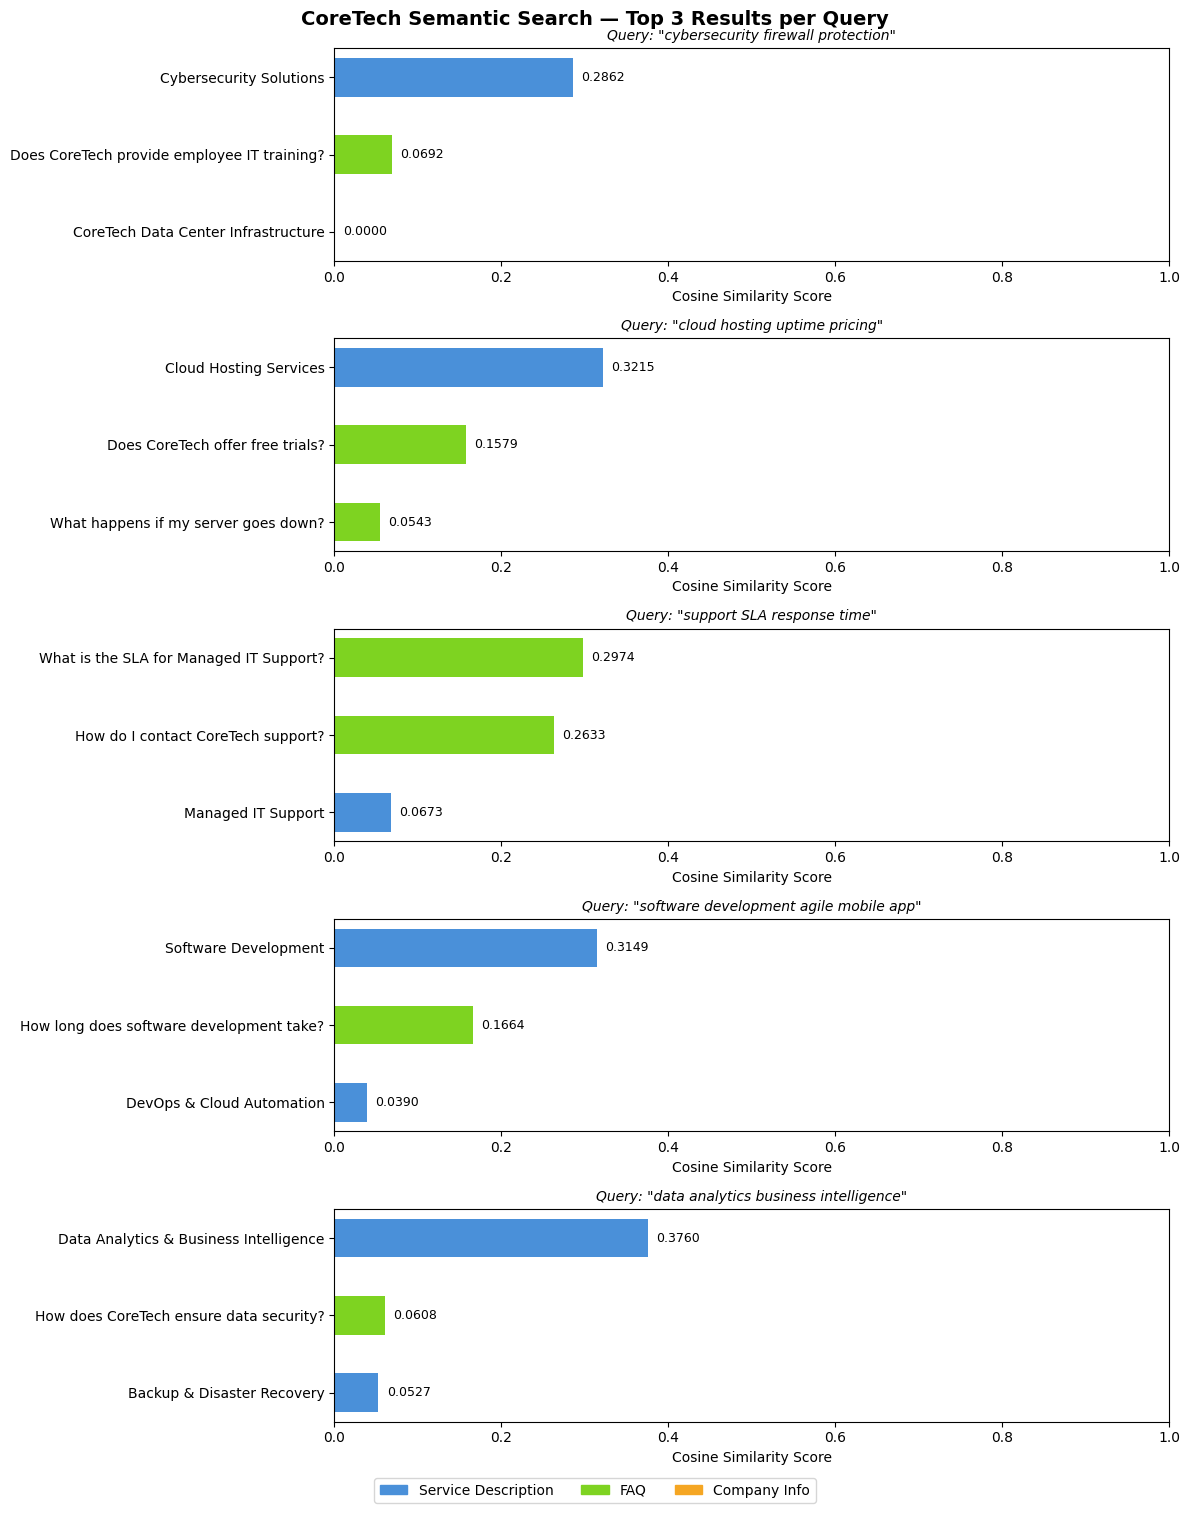

✅ Chart saved as search_results_visualization.png


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 7: VISUALISE SEARCH RESULTS AS HORIZONTAL BAR CHARTS
# One subplot per query — bars show similarity score for each
# top-3 result, color-coded by category
# ─────────────────────────────────────────────────────────────

# 5 sample queries to visualise
test_queries = [
    'cybersecurity firewall protection',
    'cloud hosting uptime pricing',
    'support SLA response time',
    'software development agile mobile app',
    'data analytics business intelligence',
]

# Color mapping for each category (used to color the bars)
colors = {
    'Service Description': '#4A90D9',  # Blue
    'FAQ':                 '#7ED321',  # Green
    'Company Info':        '#F5A623',  # Orange
}

# Create a figure with one subplot (row) per query
fig, axes = plt.subplots(len(test_queries), 1, figsize=(12, 3 * len(test_queries)))
fig.suptitle('CoreTech Semantic Search — Top 3 Results per Query',
             fontsize=14, fontweight='bold')

for ax, q in zip(axes, test_queries):
    # Run search for this query
    res = semantic_search(q)

    # Map each result's category to its assigned color
    bar_colors = [colors.get(c, '#999') for c in res['category']]

    # Draw horizontal bars: y-axis = document titles, x-axis = similarity score
    bars = ax.barh(res['title'], res['similarity_score'], color=bar_colors, height=0.5)

    ax.set_xlim(0, 1)                                      # Score range is always 0 to 1
    ax.set_xlabel('Cosine Similarity Score')
    ax.set_title(f'Query: "{q}"', fontsize=10, style='italic')

    # Add score labels at the end of each bar
    for bar, score in zip(bars, res['similarity_score']):
        ax.text(score + 0.01,                              # Slightly right of bar end
                bar.get_y() + bar.get_height() / 2,        # Vertically centered on bar
                f'{score:.4f}',                            # Display score with 4 decimal places
                va='center', fontsize=9)

    ax.invert_yaxis()  # Show Rank #1 at the top

# Build a shared color legend at the bottom of the figure
patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()

# Save chart as an image file — downloadable from the Colab Files panel
plt.savefig('search_results_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as search_results_visualization.png")

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 8: PRINT A SUMMARY OF THE KNOWLEDGE BASE AND TF-IDF INDEX
# Useful to confirm everything was built correctly
# ─────────────────────────────────────────────────────────────

print("📊 KNOWLEDGE BASE SUMMARY")
print("─" * 40)

# Total number of records in the dataset
print(f"Total records     : {len(df)}")

# Number of unique terms the vectorizer learned across all documents
print(f"Vocabulary size   : {len(vectorizer.vocabulary_)} terms")

# Shape of the TF-IDF matrix: rows = documents, columns = vocabulary terms
print(f"TF-IDF matrix     : {tfidf_matrix.shape[0]} docs × {tfidf_matrix.shape[1]} terms")

print()
print("Records per category:")
# value_counts() shows how many records belong to each category
print(df['category'].value_counts().to_string())

print()
# Average number of characters in the content column — indicates how detailed records are
print("Avg content length:", int(df['content'].str.len().mean()), "chars")

📊 KNOWLEDGE BASE SUMMARY
────────────────────────────────────────
Total records     : 34
Vocabulary size   : 1305 terms
TF-IDF matrix     : 34 docs × 1305 terms

Records per category:
category
FAQ                    15
Service Description    11
Company Info            8

Avg content length: 210 chars
